# FlashEats — Class 5 Investigation

## Client escalation

> **“Late deliveries are increasing and customers say our ETA is unreliable. Figure out what is happening before we invest in an AI delay-prediction system.”**

Today is not a syntax lesson. Your job is to use SQL, CSV, JSON and APIs like an FDE:

**define the question → retrieve evidence → validate completeness → reconcile sources → state what you know and what you still cannot know**

### Rules
- Do not train an ML model.
- State your definition of **late** before calculating it.
- Preserve raw API responses.
- Do not silently drop failures.
- If another team gets a different answer, investigate the definition and data grain first.

> **Solved version.** Every original prompt is kept; each TODO is filled in and a written answer follows
> each challenge. It runs from `Challenge_Solutions/` inside the project, which has the same `database/`,
> `data/` and `api/` folders as the classroom pack.

In [1]:
# Setup - needs pandas, requests, flask, matplotlib
import os, sys, json, time, sqlite3, subprocess
from pathlib import Path

import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

# find the folder that holds database/flasheats.db (the project root, one level up from this notebook)
BASE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "database" / "flasheats.db").exists())
print("Pack root found:", BASE.name, "| database:", (BASE / "database" / "flasheats.db").exists())

Pack root found: sst-FDE-ass-2-flasheats-pipeline | database: True


## 2. Source map first

Before analysis, predict where you would look for:

| Information | Likely source | Why? |
|---|---|---|
| Promised delivery time |  |  |
| Actual delivery time |  |  |
| Driver assignment |  |  |
| Customer complaint |  |  |
| Restaurant status |  |  |
| Driver movement/events |  |  |

**Discuss:** Which source is authoritative for each fact, and which is only contextual?

**Answer - source map**

| Information | Likely source | Why? |
|---|---|---|
| Promised delivery time | `orders.promised_eta` (SQL) - **authoritative** | the promise shown at checkout; dispatch's `current_delivery_eta` is a *revised* estimate, only contextual |
| Actual delivery time | `orders.actual_delivery_at` (SQL) - authoritative | driver app `delivered` event is a backup |
| Driver assignment | Dispatch API - authoritative | the orders table only keeps the first driver |
| Customer complaint | `support_tickets.csv` - contextual | explains the experience; messy, so not for calculating the KPI |
| Restaurant status | `restaurant_status.csv` - contextual | only the latest status, for about a third of orders |
| Driver movement/events | `driver_events.json` - contextual | GPS pings are sparse; no arrival-at-restaurant event |

In [2]:
# 3. BASIC SYNTAX - READ EVERY SOURCE
con = sqlite3.connect(BASE / "database" / "flasheats.db")
display(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", con))
display(pd.read_sql("SELECT * FROM orders LIMIT 5;", con))

tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
display(tickets.head())

with open(BASE / "data" / "driver_events.json", "r") as f:
    driver_events = json.load(f)
print("Driver objects:", len(driver_events))

,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Driver objects: 120


# Challenge 1 — How large is the late-delivery problem?

Before coding, decide:

- **Late means:** ______________________________
- **Denominator:** _____________________________
- **Cancelled orders:** include / exclude / other?
- **Missing actual delivery timestamp:** what will you do?
- **Row grain:** what does one row represent?

### Required analysis
1. valid delivered orders,
2. late count and percentage,
3. median lateness among late orders,
4. worst delayed orders,
5. any data-quality issue that changes the metric.

**Decisions made before querying**

- **Late means:** delivered after `orders.promised_eta` (the ETA shown to the customer) - any minute counts.
- **Denominator:** delivered orders that have an `actual_delivery_at`.
- **Cancelled orders:** excluded - they were never delivered, so they are neither late nor on time.
- **Missing actual delivery timestamp:** excluded from the denominator and reported, not guessed.
- **Row grain:** one row per `order_id` - duplicate rows are removed, keeping the first copy.

In [3]:
con = sqlite3.connect(BASE / "database" / "flasheats.db")

query = '''
WITH ranked AS (
    SELECT o.*, ROW_NUMBER() OVER (PARTITION BY o.order_id ORDER BY o.rowid) AS copy_no
    FROM orders o
),
one_per_order AS (SELECT * FROM ranked WHERE copy_no = 1)
SELECT
    (SELECT COUNT(*) FROM orders)                                                    AS raw_rows,
    COUNT(*)                                                                         AS unique_orders,
    SUM(LOWER(TRIM(final_status)) = 'cancelled')                                     AS cancelled,
    SUM(LOWER(TRIM(final_status)) = 'delivered' AND actual_delivery_at IS NULL)      AS delivered_no_time,
    SUM(LOWER(TRIM(final_status)) = 'delivered' AND actual_delivery_at IS NOT NULL)  AS valid_delivered,
    SUM(LOWER(TRIM(final_status)) = 'delivered' AND actual_delivery_at IS NOT NULL
        AND julianday(actual_delivery_at) > julianday(promised_eta))                 AS late
FROM one_per_order
'''
size = pd.read_sql(query, con)
size["late_pct"] = (100 * size["late"] / size["valid_delivered"]).round(1)
size

,raw_rows,unique_orders,cancelled,delivered_no_time,valid_delivered,late,late_pct
0,1603,1600,68,37,1495,843,56.4


In [4]:
# Same numbers in pandas, plus median lateness and the worst orders
orders = pd.read_sql("SELECT * FROM orders", con)
order_analysis = orders.drop_duplicates("order_id", keep="first").copy()
for c in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
    order_analysis[c] = pd.to_datetime(order_analysis[c], format="mixed", errors="coerce")
order_analysis["status"] = order_analysis["final_status"].str.strip().str.lower()
order_analysis["delay_min"] = (order_analysis["actual_delivery_at"] - order_analysis["promised_eta"]).dt.total_seconds() / 60

valid = order_analysis[(order_analysis["status"] == "delivered") & order_analysis["actual_delivery_at"].notna()].copy()
valid["late"] = valid["delay_min"] > 0
late_orders = valid[valid["late"]]

print(f"1. Valid delivered orders: {len(valid)}")
print(f"2. Late: {len(late_orders)} ({valid['late'].mean():.1%})")
print(f"3. Median lateness among late orders: {late_orders['delay_min'].median():.1f} min")
print("4. Worst delayed orders:")
display(late_orders.nlargest(5, "delay_min")[["order_id", "restaurant_id", "promised_eta", "actual_delivery_at", "delay_min", "traffic_bucket"]])

1. Valid delivered orders: 1495
2. Late: 843 (56.4%)
3. Median lateness among late orders: 8.0 min
4. Worst delayed orders:


,order_id,restaurant_id,promised_eta,actual_delivery_at,delay_min,traffic_bucket
103,O00104,R031,2026-08-09 22:09:00.000000,2026-08-09 23:36:20.740161,87.345669,medium
101,O00102,R004,2026-08-11 16:31:00.000000,2026-08-11 17:57:17.661772,86.294363,medium
100,O00101,R007,2026-08-24 20:49:00.000000,2026-08-24 22:14:30.685278,85.511421,low
102,O00103,R020,2026-08-22 20:01:00.000000,2026-08-22 21:10:17.342305,69.289038,high
1080,O01081,R048,2026-08-13 18:15:46.613098,2026-08-13 19:06:02.677891,50.267747,high


In [5]:
# 5. Data-quality issues that change the metric
dups = orders[orders["order_id"].duplicated(keep=False)]
differ = sorted({c for _, g in dups.groupby("order_id") for c in g.columns if g[c].nunique(dropna=False) > 1})
dq = pd.DataFrame([
    ("duplicate order rows", len(orders) - orders["order_id"].nunique(), "copies differ only on: " + ", ".join(differ)),
    ("'Delivered' vs 'delivered'", int((orders["final_status"] == "Delivered").sum()), "same meaning - normalised"),
    ("delivered but no actual_delivery_at", int(((order_analysis["status"] == "delivered") & order_analysis["actual_delivery_at"].isna()).sum()), "left out of the denominator"),
    ("promised_eta before created_at", int((order_analysis["promised_eta"] < order_analysis["created_at"]).sum()), "the promise itself looks invalid"),
    ("delivered before pickup", int((order_analysis["actual_delivery_at"] < order_analysis["pickup_at"]).sum()), "chronology broken"),
], columns=["issue", "rows", "impact"])
dq

,issue,rows,impact
0,duplicate order rows,3,copies differ only on: traffic_bucket
1,'Delivered' vs 'delivered',5,same meaning - normalised
2,delivered but no actual_delivery_at,37,left out of the denominator
3,promised_eta before created_at,4,the promise itself looks invalid
4,delivered before pickup,5,chronology broken


**Answer - Challenge 1**

- 1,603 rows but only **1,600 orders**: 3 orders appear twice (the copies differ only on `traffic_bucket`).
- 68 orders were cancelled and **37 delivered orders have no delivery time**, leaving **1,495 valid delivered orders**.
- **843 of 1,495 are late = 56.4%.** Median lateness among late orders is about **8 minutes**; the worst is 87 minutes.
- Issues that change the metric: the 37 missing delivery times (if they could be recovered, the denominator changes),
  4 orders whose promise is *before* the order was placed, and 5 orders "delivered" before pickup. If another team
  got a different number, these - plus not removing duplicates, or counting cancelled orders - are the first things to compare.

## Checkpoint

Compare your answer with another team.

If your counts differ, investigate:
- duplicate rows,
- cancelled orders,
- missing timestamps,
- late-delivery definition,
- row grain.

# Challenge 2 — Operations says: “Traffic is the problem.”

Test that claim using at least three dimensions.

Possible dimensions:
- traffic,
- weather,
- distance,
- time of day,
- restaurant,
- driver.

### Required output
- 2–3 comparisons,
- one chart or compact table,
- one hypothesis supported by evidence,
- one alternative explanation you cannot rule out.

Separate **association** from **causation**.

In [6]:
valid["traffic"] = valid["traffic_bucket"].str.strip().str.lower()
valid["distance_band"] = pd.cut(valid["distance_km_estimate"], [0, 5, 10, 17.99, 18.0, 100], include_lowest=True,
                                labels=["0-5 km", "5-10 km", "10-18 km", "exactly 18.0 km", "over 18 km"])
valid["time_of_day"] = pd.cut(valid["created_at"].dt.hour, [0, 14, 17, 21, 24], right=False,
                              labels=["lunch (to 14h)", "afternoon (14-17h)", "dinner (17-21h)", "late (21h+)"])
valid["to_pickup_min"] = (valid["pickup_at"] - valid["created_at"]).dt.total_seconds() / 60
valid["drive_min"] = (valid["actual_delivery_at"] - valid["pickup_at"]).dt.total_seconds() / 60

def compare(col):
    return (valid.groupby(col, observed=True)
            .agg(orders=("order_id", "size"), late_rate=("late", "mean"), median_delay=("delay_min", "median"),
                 median_order_to_pickup=("to_pickup_min", "median"), median_drive=("drive_min", "median"))
            .round(3))

for col in ["traffic", "weather_bucket", "distance_band", "time_of_day"]:
    print("\n==", col)
    display(compare(col))


== traffic


,orders,late_rate,median_delay,median_order_to_pickup,median_drive
traffic,,,,,
high,424,0.665,3.992,26.984,53.022
low,360,0.494,-0.095,25.820,43.477
medium,588,0.514,0.263,25.884,46.738
severe,123,0.659,4.264,25.530,61.791



== weather_bucket


,orders,late_rate,median_delay,median_order_to_pickup,median_drive
weather_bucket,,,,,
clear,1192,0.533,0.778,26.153,45.990
heavy_rain,72,0.736,6.630,24.777,60.023
rain,231,0.671,4.268,26.530,51.874



== distance_band


,orders,late_rate,median_delay,median_order_to_pickup,median_drive
distance_band,,,,,
0-5 km,69,0.536,0.591,25.054,20.048
5-10 km,222,0.559,1.015,25.657,30.782
10-18 km,452,0.562,1.622,26.752,43.888
exactly 18.0 km,749,0.567,1.442,25.949,52.181
over 18 km,3,1.000,26.320,49.647,55.873



== time_of_day


,orders,late_rate,median_delay,median_order_to_pickup,median_drive
time_of_day,,,,,
lunch (to 14h),311,0.559,1.186,26.069,48.606
afternoon (14-17h),206,0.602,2.145,27.047,47.267
dinner (17-21h),729,0.569,1.650,26.074,47.120
late (21h+),249,0.522,0.961,24.980,45.300


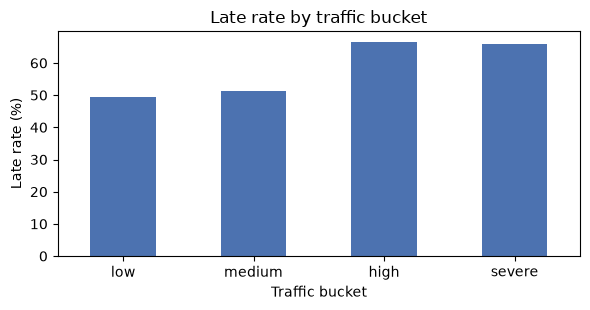

In [7]:
ax = (compare("traffic").reindex(["low", "medium", "high", "severe"])["late_rate"] * 100).plot(
    kind="bar", color="#4C72B0", figsize=(6, 3.2))
ax.set_ylabel("Late rate (%)"); ax.set_xlabel("Traffic bucket"); ax.set_title("Late rate by traffic bucket")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Answer - Challenge 2**

- **Traffic:** late rate rises from 49.4% (low) to 66.5% (high) and 65.9% (severe). The time *to pickup* is about
  26 minutes in every bucket; what changes is the **drive** (median 43 min in low traffic vs 53-62 min in high/severe).
- **Weather:** clear 53.3%, rain 67.1%, heavy rain 73.6% - same pattern, longer drives.
- **Distance:** no real difference (54-57% in every band) - and half the orders are exactly 18.0 km, which looks
  like a cap, so this field can't support a conclusion either way.
- **Time of day:** 52-60%, no strong pattern.

**Hypothesis supported by the evidence:** bad traffic and rain are *associated* with longer drives and a higher late rate.

**But traffic is not "the problem" on its own:** even in low traffic, half the orders are late. Something besides
the road is making orders late.

**Alternative explanation we can't rule out:** the promised ETA may simply be too tight, or orders may be leaving
the restaurant late. The orders table can't tell us when the driver *should* have picked up - we need dispatch's
plan for that (Challenge 4). All of this is association, not causation: busy, rainy evenings also mean busier
kitchens and more orders per driver.

# Challenge 3 — Customer Support disagrees

Use `support_tickets.csv`.

### Questions
1. What are customers actually complaining about?
2. Which complaint types are most common?
3. Are ticket IDs unique?
4. Does the customer story match the operational story?
5. What can tickets tell you that timestamps cannot?

### Required output
A short **system view vs customer view** comparison.

In [8]:
tickets["category_clean"] = tickets["category"].str.strip().str.lower().str.replace(" ", "_")
print("Rows:", len(tickets), "| unique ticket_id:", tickets["ticket_id"].nunique(),
      "| exact duplicate rows:", int(tickets.duplicated().sum()), "| tickets with no order_id:", int(tickets["order_id"].isna().sum()))
display(tickets[tickets["ticket_id"].duplicated(keep=False)])

t = tickets.drop_duplicates()
valid["late_f"] = valid["late"].astype(float)
by_category = (t.merge(valid[["order_id", "late_f", "delay_min"]], on="order_id", how="left")
               .groupby("category_clean")
               .agg(tickets=("ticket_id", "size"), share_on_late_orders=("late_f", "mean"), median_delay_min=("delay_min", "median"))
               .sort_values("tickets", ascending=False).round(2))
display(by_category)

on_time_tickets = t.merge(valid[["order_id", "late"]], on="order_id")
print("Tickets about orders that were delivered ON TIME:", int((~on_time_tickets["late"]).sum()), "of", len(on_time_tickets))

Rows: 202 | unique ticket_id: 201 | exact duplicate rows: 1 | tickets with no order_id: 3


,ticket_id,order_id,created_at,category,customer_message,category_clean
12,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.,late_delivery
201,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.,late_delivery


,tickets,share_on_late_orders,median_delay_min
category_clean,,,
late_delivery,39,0.87,14.78
restaurant_delay,37,0.76,10.45
eta_changed,37,0.80,7.65
ready_but_waiting,33,0.91,12.16
status_mismatch,29,0.93,12.68
driver_not_moving,25,0.68,10.37
eta_issue,1,1.00,5.40


Tickets about orders that were delivered ON TIME: 34 of 197


**Answer - Challenge 3**

1-2. The biggest complaint types are `late_delivery` (39 once spelling is fixed and the duplicate ticket removed), `eta_changed` (37),
`restaurant_delay` (37), `ready_but_waiting` (33), `status_mismatch` (29) and `driver_not_moving` (25).
3. **Ticket IDs are not unique** - `T00013` appears twice as an exact copy. 3 tickets have no order_id and can't be
linked. Spelling differs (`Late Delivery`, `late_delivery `) and `ETA issue` doesn't fit any category.

| System view (timestamps) | Customer view (tickets) |
|---|---|
| 56.4% of orders arrive after the promised ETA | Most complaints are about the **restaurant hand-off** (`restaurant_delay`, `ready_but_waiting`, `status_mismatch`), not traffic |
| Traffic/rain are associated with longer drives | Customers complain the **ETA keeps changing** (`eta_changed`) - the promise moves after checkout |
| An order is "on time" if it meets the promise | 34 tickets are about orders that were on time - the experience can be bad even when the metric says fine |

5. Tickets tell us *what the customer experienced* (food ready but waiting, ETA moving, driver not moving) - things
no timestamp captures. They are not a clean operational source (duplicates, missing order links, messy categories),
so they explain the metric but shouldn't be used to calculate it.

# Challenge 4 — Dispatch API: prove you retrieved everything

Your task:
1. start the API,
2. inspect one response,
3. retrieve **all** records,
4. handle pagination,
5. handle retryable failures,
6. save every successful raw page,
7. prove ingestion completeness.

A successful HTTP `200` on one page does **not** prove the job succeeded.

In [9]:
# Start the mock Dispatch API and wait until it answers
api_script = BASE / "api" / "mock_dispatch_api.py"
api_proc = subprocess.Popen([sys.executable, str(api_script)], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

for _ in range(30):
    try:
        health = requests.get("http://127.0.0.1:8000/health", timeout=1)
        break
    except requests.RequestException:
        time.sleep(0.5)
print(health.status_code, health.json())

200 {'service': 'flasheats-dispatch-api', 'status': 'ok'}


In [10]:
# Basic API syntax
API_URL = "http://127.0.0.1:8000/dispatch/orders"

response = requests.get(
    API_URL,
    params={"page": 1, "page_size": 50},
    timeout=10
)

print("HTTP:", response.status_code)

if response.ok:
    payload = response.json()
    print("Keys:", payload.keys())
    print("Records on page:", len(payload["data"]))
    print("Has more:", payload["has_more"])
    print("Reported total:", payload["total_records"])

HTTP: 200
Keys: dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records'])
Records on page: 50
Has more: True
Reported total: 1600


In [11]:
API_URL = "http://127.0.0.1:8000/dispatch/orders"
RAW_DIR = Path.cwd() / "raw_dispatch"          # raw pages are saved next to this notebook
RAW_DIR.mkdir(parents=True, exist_ok=True)
for old in RAW_DIR.glob("page_*.json"):
    old.unlink()

def fetch_all_dispatch_orders(page_size=100, max_retries=4):
    '''Fetch every page, retry 429/5xx, save each raw page, fail loudly if anything is missing.'''
    records, attempts, page = [], [], 1
    while True:
        for attempt in range(1, max_retries + 1):
            r = requests.get(API_URL, params={"page": page, "page_size": page_size}, timeout=10)
            attempts.append({"page": page, "attempt": attempt, "status": r.status_code})
            if r.status_code == 200:
                break
            if r.status_code in (429, 500, 502, 503, 504):
                wait = r.json().get("retry_after_seconds", 2 ** (attempt - 1)) if r.status_code == 429 else 2 ** (attempt - 1)
                print(f"page {page}, attempt {attempt}: HTTP {r.status_code} -> retrying in {wait}s")
                time.sleep(wait)
                continue
            raise RuntimeError(f"page {page}: HTTP {r.status_code} is not retryable - ingestion INCOMPLETE")
        else:
            raise RuntimeError(f"page {page} still failing after {max_retries} attempts - ingestion INCOMPLETE")

        (RAW_DIR / f"page_{page:03d}.json").write_text(r.text, encoding="utf-8")   # raw, exactly as received
        payload = r.json()
        records.extend(payload["data"])
        expected_total = payload["total_records"]
        if not payload["has_more"]:
            break
        page += 1
    return records, expected_total, pd.DataFrame(attempts)

dispatch_records, expected_total, attempts = fetch_all_dispatch_orders()
print("Retrieved:", len(dispatch_records))

page 3, attempt 1: HTTP 500 -> retrying in 1s


page 5, attempt 1: HTTP 429 -> retrying in 1s


Retrieved: 1600


In [12]:
# Prove the ingestion is complete - one 200 response is not proof
dispatch = pd.DataFrame(dispatch_records)
raw_files = sorted(RAW_DIR.glob("page_*.json"))
proof = pd.DataFrame([
    ("records retrieved = API's reported total", f"{len(dispatch)} vs {expected_total}", len(dispatch) == expected_total),
    ("no duplicate order_ids", f"{dispatch['order_id'].nunique()} unique", dispatch["order_id"].nunique() == len(dispatch)),
    ("same orders as the orders table", f"{len(set(dispatch['order_id']) ^ set(order_analysis['order_id']))} differ",
     set(dispatch["order_id"]) == set(order_analysis["order_id"])),
    ("every page saved raw", f"{len(raw_files)} files for {attempts['page'].nunique()} pages", len(raw_files) == attempts["page"].nunique()),
], columns=["check", "value", "pass"])
display(proof)
print("Failed attempts that were retried:")
display(attempts[attempts["status"] != 200])

# what dispatch adds that the orders table doesn't have
d = valid.merge(dispatch[["order_id", "current_delivery_eta", "original_driver_id", "driver_id"]], on="order_id",
                suffixes=("_orders", "_dispatch"))
d["current_eta"] = pd.to_datetime(d["current_delivery_eta"], format="mixed")
print(f"Late vs the ORIGINAL promise:             {(d['actual_delivery_at'] > d['promised_eta']).mean():.1%}")
print(f"Late vs dispatch's CURRENT (revised) ETA: {(d['actual_delivery_at'] > d['current_eta']).mean():.1%}")
print("Orders reassigned to another driver:", int((dispatch["driver_id"] != dispatch["original_driver_id"]).sum()))

,check,value,pass
0,records retrieved = API's reported total,1600 vs 1600,True
1,no duplicate order_ids,1600 unique,True
2,same orders as the orders table,0 differ,True
3,every page saved raw,16 files for 16 pages,True


Failed attempts that were retried:


,page,attempt,status
2,3,1,500
5,5,1,429


Late vs the ORIGINAL promise:             56.4%
Late vs dispatch's CURRENT (revised) ETA: 25.9%
Orders reassigned to another driver: 95


**Answer - Challenge 4**

The API fails on purpose: page 3 returns **HTTP 500** and page 5 returns **HTTP 429** the first time. Both are retried
(the 429 waits as long as the API asks), every successful page is saved raw, and the job only counts as successful
because all four completeness checks pass: 1,600 records = the API's reported total, no duplicate IDs, exactly the
same orders as the orders table, and one raw file per page.

Dispatch also changes the picture: it keeps a **revised ETA**. Measured against that, only about 26% of orders are late
instead of 56% - so the KPI must say which ETA is "the promise" (the customer saw the original one). And 95 orders were
reassigned, so `orders.driver_id` is the *first* driver, not necessarily the one who delivered.

# Challenge 5 — Can we attribute the delay?

Inspect `driver_events.json`.

Look for:
- assignment,
- GPS pings,
- pickup,
- delivery.

Then answer:

> **Can we reliably tell when the driver arrived at the restaurant?**

Be precise about:
- **Observed** = directly stored.
- **Inferred** = estimated from another signal, such as GPS.

### Required output

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned |  |  |  |
| Driver at restaurant |  |  |  |
| Picked up |  |  |  |
| Delivered |  |  |  |

In [13]:
# Flatten nested JSON: one row per driver event
flat_events = [{"driver_id": drv["driver_id"], **ev} for drv in driver_events for ev in drv["events"]]
driver_events_df = pd.DataFrame(flat_events)
driver_events_df["ts"] = pd.to_datetime(driver_events_df["timestamp"], format="mixed")
display(driver_events_df["type"].value_counts())

print("Explicit 'arrived at restaurant' events:", int(driver_events_df["type"].str.contains("arriv").sum()))

pings = driver_events_df[driver_events_df["type"] == "gps_ping"].sort_values(["order_id", "ts"])
gap = pings.groupby("order_id")["ts"].diff().dt.total_seconds() / 60
print(f"GPS pings per order: median {pings.groupby('order_id').size().median():.0f}, "
      f"median {gap.median():.0f} min apart")

app = driver_events_df.pivot_table(index="order_id", columns="type", values="ts", aggfunc="min")
cmp = order_analysis.set_index("order_id")[["pickup_at", "actual_delivery_at"]].join(app[["picked_up", "delivered"]])
both_pickup = cmp[["pickup_at", "picked_up"]].notna().all(axis=1)
both_delivered = cmp[["actual_delivery_at", "delivered"]].notna().all(axis=1)
print("picked_up matches orders.pickup_at (within 1s):",
      int(((cmp["pickup_at"] - cmp["picked_up"]).abs() < pd.Timedelta("1s")).sum()), "of", int(both_pickup.sum()))
print("delivered matches orders.actual_delivery_at (within 1s):",
      int(((cmp["actual_delivery_at"] - cmp["delivered"]).abs() < pd.Timedelta("1s")).sum()), "of", int(both_delivered.sum()))
print("driver app has a delivery time where the orders table has none:",
      int((cmp["delivered"].notna() & cmp["actual_delivery_at"].isna()).sum()))

type
gps_ping     5371
assigned     1600
picked_up    1532
delivered    1532
Name: count, dtype: int64

Explicit 'arrived at restaurant' events: 0
GPS pings per order: median 3, median 13 min apart
picked_up matches orders.pickup_at (within 1s): 1527 of 1532
delivered matches orders.actual_delivery_at (within 1s): 1495 of 1495
driver app has a delivery time where the orders table has none: 37


**Answer - Challenge 5: can we reliably tell when the driver arrived at the restaurant? No.**

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned | Observed | driver app (`assigned`), dispatch `assigned_at` | good; but reassignments mean the orders table shows the first driver |
| Driver at restaurant | **Not observed** - could only be *inferred* from GPS | nobody records it | pings are a median 13 min apart, far too coarse to say when the driver arrived |
| Picked up | Observed | orders `pickup_at`, driver app `picked_up` | the two agree on 1,527 of 1,532; 5 disagree by 45-60 min (the same 5 "delivered before pickup" orders) |
| Delivered | Observed | orders `actual_delivery_at`, driver app `delivered` | identical to the second on all 1,495 orders both have; the driver app also has the 37 missing ones |

So we can see *that* an order was picked up late, but not *whose* fault it was - the restaurant (food not ready) or
the driver (arrived late).

# Final FDE synthesis — one slide only

Your final slide must answer:

1. **Problem size** — how large is the late-delivery problem?
2. **Evidence** — what appears related to delay?
3. **Trusted sources** — which sources do you trust for which facts?
4. **Uncertainty** — what can you not determine confidently?
5. **Instrumentation recommendation** — what should FlashEats capture/fix next?
6. **Decision** — would you build the AI delay predictor now? Why or why not?

Use language such as:
- “The data shows…”
- “This is associated with…”
- “We cannot determine…”
- “We would need X before concluding Y…”

**Answer - final FDE slide**

1. **Problem size:** 56.4% of 1,495 valid delivered orders arrive after the promised ETA; median lateness of late orders is about 8 minutes.
2. **Evidence:** heavy traffic and rain are associated with longer drives and more late orders - but half of orders
   are late even in low traffic. Customers mostly complain about the restaurant hand-off and the ETA changing.
3. **Trusted sources:** orders table for the promise and delivery time; dispatch for assignment, reassignment and
   the revised ETA; driver app as a backup delivery time; tickets for the customer view only.
4. **Uncertainty:** we can't tell restaurant delay from driver delay; "late" has more than one possible definition
   (original vs revised ETA); distance is capped at 18 km.
5. **Instrumentation:** record *driver arrived at restaurant* and *food ready*; keep the ETA history instead of
   overwriting it; clean up ticket categories and require an order_id.
6. **Decision - would we build the AI delay predictor now? No.** We can't yet say *why* orders are late, the target
   itself ("late" against which ETA?) isn't agreed, and key events are missing. Fix the data first.

In [14]:
# Cleanup
try:
    con.close()
except Exception:
    pass
try:
    api_proc.terminate()
except Exception:
    pass
print("Session cleanup complete.")

Session cleanup complete.
